## IMPORT DATA

In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()
os.chdir("/Users/muhammadhilmy/Documents/Hilmy/Portofolio/credit-risk-mlops-portofolio")

In [3]:
df = pd.read_csv("CreditRiskData/credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## Data Check & Cleansing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")
print(f"Number of missing values: {df.isnull().sum().sum()}")

Number of duplicated rows: 165
Number of missing values: 4011


In [7]:
((df.isnull().sum())/len(df)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [8]:
((df.duplicated().sum())/len(df)) * 100

np.float64(0.506430127988705)

In [9]:
# fill the loan_int_rate column with the mean value
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)
print(f"loan interest rate column missing values: {df['loan_int_rate'].isnull().sum()}")

loan interest rate column missing values: 0


In [10]:
# drop outlier 123 years in person emp length column
df.drop(df[df['person_emp_length'] == 123].index, inplace=True)

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32579.000000,3.257900e+04,31684.000000,32579.000000,32579.000000,32579.000000,32579.000000,32579.000000
mean,27.734983,6.607120e+04,4.782224,9588.271586,11.011678,0.218147,0.170193,5.804352
std,6.348084,6.198108e+04,4.034888,6320.449757,3.081475,0.412994,0.106759,4.055084
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,11.011695,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df['person_age_bin'] = pd.cut(df['person_age'], bins=[0, 20, 30, 40, 50, 60, 70, 80, float('inf')], labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '>81'])
pd.pivot_table(df, index='person_age_bin', values=['person_emp_length', 'person_income'], aggfunc='mean')

/var/folders/m9/3gckb5c57x79c15z533vjjbr0000gn/T/ipykernel_79236/1559234622.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df, index='person_age_bin', values=['person_emp_length', 'person_income'], aggfunc='mean')


,person_emp_length,person_income
person_age_bin,,
0-20,3.333333,90810.866667
21-30,4.470383,62838.320152
31-40,5.688903,73789.183139
41-50,6.278061,79930.580431
51-60,5.446512,95266.678899
61-70,5.821429,104651.807018
71-80,13.000000,57206.666667
>81,4.571429,960972.000000


<Axes: xlabel='person_emp_length', ylabel='Count'>

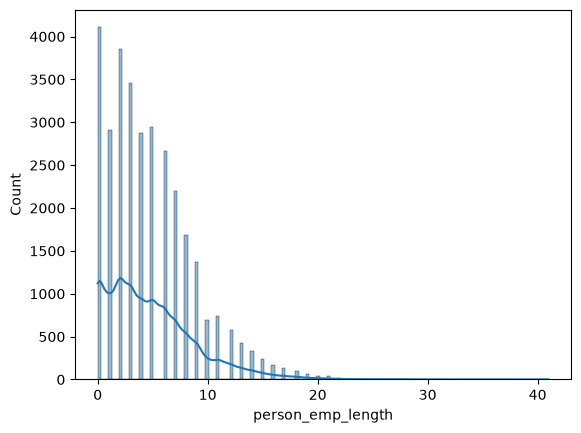

In [13]:
sns.histplot(df["person_emp_length"], kde=True)

In [14]:
person_isnull = df[df.isnull().any(axis=1)]
person_isnull['person_age'].unique()

array([22, 24, 25, 21, 26, 23, 30, 27, 31, 28, 29, 33, 35, 34, 32, 47, 38,
       40, 44, 36, 37, 42, 43, 41, 39, 48, 50, 49, 51, 70, 56, 53])

In [15]:
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=5)

df[['person_emp_length']] = knn.fit_transform(df[['person_emp_length']])

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32414 entries, 1 to 32580
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32414 non-null  int64   
 1   person_income               32414 non-null  int64   
 2   person_home_ownership       32414 non-null  object  
 3   person_emp_length           32414 non-null  float64 
 4   loan_intent                 32414 non-null  object  
 5   loan_grade                  32414 non-null  object  
 6   loan_amnt                   32414 non-null  int64   
 7   loan_int_rate               32414 non-null  float64 
 8   loan_status                 32414 non-null  int64   
 9   loan_percent_income         32414 non-null  float64 
 10  cb_person_default_on_file   32414 non-null  object  
 11  cb_person_cred_hist_length  32414 non-null  int64   
 12  person_age_bin              32414 non-null  category
dtypes: category(1), float

In [18]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,21-30
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,21-30
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,21-30
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,21-30
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,21-30


## EDA

In [19]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.781329
1    0.218671
Name: proportion, dtype: float64

In [20]:
# count of loan status by loan intent
pd.crosstab(df['loan_intent'], df['loan_status'], normalize=True)

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,0.114179,0.045906
EDUCATION,0.163664,0.034121
HOMEIMPROVEMENT,0.081878,0.029000
MEDICAL,0.136515,0.049886
PERSONAL,0.135867,0.033720
VENTURE,0.149226,0.026038


In [21]:
pd.crosstab(df['loan_grade'], df['loan_status'], normalize=True)

loan_status,0,1
loan_grade,,
A,0.297279,0.032887
B,0.268156,0.052292
C,0.157401,0.041217
D,0.045721,0.065928
E,0.010551,0.019158
F,0.002190,0.005245
G,0.000031,0.001944


In [22]:
df['cb_person_default_on_file'].value_counts(normalize=True)

cb_person_default_on_file
N    0.823255
Y    0.176745
Name: proportion, dtype: float64

In [23]:
pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize=True)

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.360369,0.052045
OTHER,0.002252,0.001018
OWN,0.073147,0.005923
RENT,0.345561,0.159684


In [24]:
pd.crosstab(df['person_age_bin'], df['loan_status'], normalize=True)

loan_status,0,1
person_age_bin,,
0-20,0.000401,0.000062
21-30,0.591164,0.169526
31-40,0.153576,0.039273
41-50,0.029555,0.007558
51-60,0.004998,0.001728
61-70,0.001234,0.000524
71-80,0.000185,0.000000
>81,0.000216,0.000000


In [25]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_age_bin
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,21-30
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,21-30
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,21-30
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,21-30
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,21-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,51-60
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,51-60
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,61-70
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,51-60


## Modelling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

#df_encoded = pd.get_dummies(df, columns=['loan_intent', 'loan_grade', 'person_home_ownership', 'cb_person_default_on_file'], drop_first=True)

X = df.drop(columns=['loan_status', 'person_age_bin'])
y = df['loan_status']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [28]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

cat_col = ['loan_intent', 'loan_grade', 'person_home_ownership', 'cb_person_default_on_file']

ohe.fit(X_train[cat_col])

X_train_ohe = ohe.transform(X_train[cat_col])

X_train_ohe = pd.DataFrame(
    X_train_ohe,
    columns=ohe.get_feature_names_out(cat_col),
    index=X_train.index
)

X_train_num = X_train.drop(columns=cat_col)

X_train_final = pd.concat([X_train_num, X_train_ohe], axis=1)

X_train_final.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,cb_person_default_on_file_Y
18469,30,110000,5.0,20000,14.11,0.18,5,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
13471,23,92000,4.0,15600,16.35,0.17,3,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
30441,43,45000,2.0,7000,12.99,0.16,14,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2494,25,17400,0.0,3000,11.83,0.17,4,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10129,22,43000,1.0,9575,6.62,0.22,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [29]:
ohe.fit(X_test[cat_col])
X_test_ohe = ohe.transform(X_test[cat_col])
X_test_ohe = pd.DataFrame(
    X_test_ohe,
    columns=ohe.get_feature_names_out(cat_col),
    index=X_test.index
)
X_test_num = X_test.drop(columns=cat_col)
X_test_final = pd.concat([X_test_num, X_test_ohe], axis=1)
X_test_final.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,...,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,cb_person_default_on_file_Y
2363,21,42000,5.0,2500,9.99,0.06,2,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
14362,22,105000,2.0,15000,15.95,0.14,3,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
15887,21,249996,5.0,5000,8.59,0.02,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28264,33,50800,16.0,10000,16.40,0.20,10,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
14495,26,36108,7.0,2000,16.49,0.06,3,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
lr = LogisticRegression(max_iter=300)
lr.fit(X_train_final, y_train)

/Users/muhammadhilmy/Documents/Hilmy/Portofolio/credit-risk-mlops-portofolio/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",300
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [31]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred = lr.predict(X_test_final)
y_pred_proba_train = lr.predict_proba(X_train_final)[:, 1]
y_pred_proba_test = lr.predict_proba(X_test_final)[:, 1]

roc_train = roc_auc_score(y_train, y_pred_proba_train)
roc_test = roc_auc_score(y_test, y_pred_proba_test)

# Evaluasi
print("ROC AUC Score Train:", roc_train)
print("ROC AUC Score Test:", roc_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC AUC Score Train: 0.8421619306558379
ROC AUC Score Test: 0.8474033454389658

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6352
           1       0.75      0.43      0.55      1752

    accuracy                           0.85      8104
   macro avg       0.81      0.70      0.73      8104
weighted avg       0.84      0.85      0.83      8104


Confusion Matrix:
[[6104  248]
 [ 995  757]]


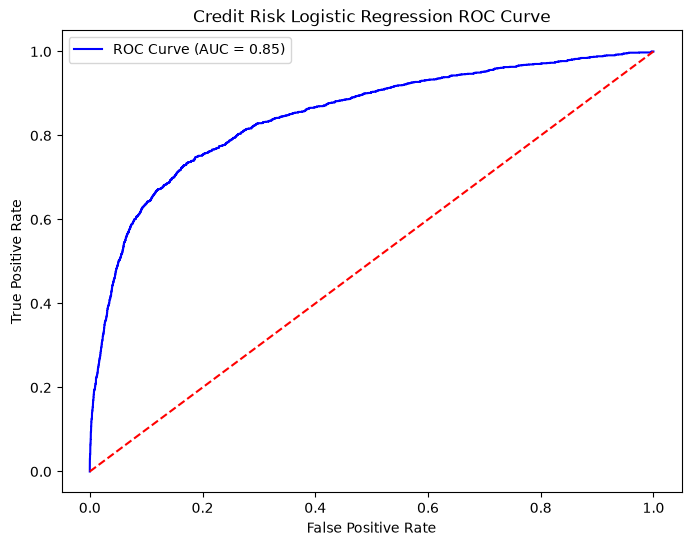

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba_test)))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Credit Risk Logistic Regression ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

/Users/muhammadhilmy/Documents/Hilmy/Portofolio/credit-risk-mlops-portofolio/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 24310 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24310 when initializing the masker.


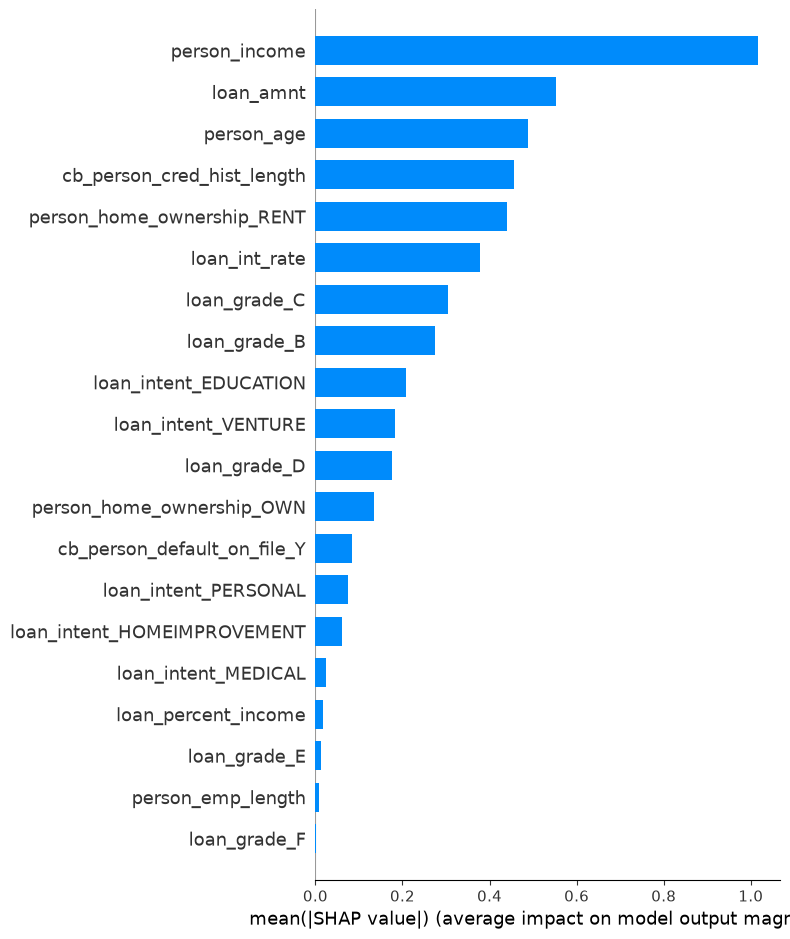

In [33]:
import shap

explainer = shap.Explainer(lr, X_train_final)
shap_values = explainer(X_test_final)
shap.summary_plot(shap_values, X_test_final, plot_type="bar")